# 05 Adavanced Models

Gradient Boosting (e.g., XGBoost or LightGBM). 
Perform light hyperparameter tuning (depth, learning rate, n_estimators). 

## Setup

In [ ]:
# %pip install lightgbm
# %pip install xgboost

import os, glob
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 100)

DATA = sorted(glob.glob('../../data/cleaned_CRMLSSold*.csv'))[-1]
RESULTS = '../../results/model_results.csv'

TARGET = 'ClosePrice'
DATE = 'CloseDate'

df = pd.read_csv(DATA, parse_dates=[DATE])
print(f"loaded {DATA}  ->  {df.shape[0]:,} rows x {df.shape[1]} columns")

TEST_MONTH = (pd.read_csv(DATA, usecols=[DATE], parse_dates=[DATE])[DATE].dt.to_period("M").astype(str).max())
MAX_TRAIN_MONTHS = 11 

avail_data = (pd.read_csv(DATA, usecols=[DATE], parse_dates=[DATE])[DATE].dt.to_period("M").nunique() - 1)
TRAIN_MONTHS = min(avail_data, MAX_TRAIN_MONTHS)

RANDOM_STATE = 42 #needed for decision tree and random forest
print(f"Using {DATA}  |  test month = {TEST_MONTH}  |  train window = {TRAIN_MONTHS} months")

WEEK = 7

C:\Users\Vivian\AppData\Local\Temp\ipykernel_18692\366284295.py:30: DtypeWarning: Columns (0: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA, parse_dates=[DATE])


loaded ../../data\cleaned_CRMLSSold202506_202606.csv  ->  142,750 rows x 1567 columns
Using ../../data\cleaned_CRMLSSold202506_202606.csv  |  test month = 2026-06  |  train window = 11 months


In [2]:
#split data into train/test sets

def chrono_split(data, test_month=TEST_MONTH, window=TRAIN_MONTHS, date=DATE):

      months = data[date].dt.to_period("M")
      test_p = pd.Period(test_month, freq="M")
      train_start = test_p - window 

      test = data[months == test_p]
      train = data[(months >= train_start) & (months < test_p)]
      # Error checks
      assert len(train) > 0 and len(test) > 0, "ERROR: Empty split (check params)"
      assert train[date].max() < test[date].min(), "Chronology violated"
      return train, test

train_df, test_df = chrono_split(df)

print(f"Train: {train_df.shape[0]:,} rows "f"({train_df[DATE].min().date()} --> {train_df[DATE].max().date()})")
print(f"Test:  {test_df.shape[0]:,} rows "f"({test_df[DATE].min().date()} --> {test_df[DATE].max().date()})")

Train: 118,247 rows (2025-07-01 --> 2026-05-31)
Test:  12,837 rows (2026-06-01 --> 2026-06-30)


In [3]:
# trim to train 1/99 bounds
def trim_to_train_bounds(train, test, target=TARGET, low=0.01, high=0.99):
    lo, hi = train[target].quantile(low), train[target].quantile(high)
    return (train[train[target].between(lo, hi)].copy(),
            test[test[target].between(lo, hi)].copy(), lo, hi)

test_df_full = test_df.copy()
_ntr, _nte = len(train_df), len(test_df)
train_df, test_df, TRIM_LO, TRIM_HI = trim_to_train_bounds(train_df, test_df)
print(f"Trim bounds (train 1/99): ${TRIM_LO:,.0f} - ${TRIM_HI:,.0f}")
print(f"Train: {_ntr:,} -> {len(train_df):,} | Test: {_nte:,} -> {len(test_df):,}")

Trim bounds (train 1/99): $235,000 - $6,300,000
Train: 118,247 -> 115,941 | Test: 12,837 -> 12,570


In [4]:
EXCLUDE = [
    "ListingKey",              
    "CloseDate", "CloseMonth",  

    "ClosePrice",               # target var
    "ClosePrice_log",           # target in log form
    "ClosePrice_repaired",      # metadata

    "CountyOrParish",           # one-hots from 02_preprocessing
    "PostalCode",               

    "LivingArea",               # using LivingArea_log
    "LotSizeAcres",             # using LotSizeAcres_log

    "County_Los_Angeles",       # reference
    "SchoolDistrict",
    "BedBathRatio", 
    "PropertyAge", 
    "LotToLiving_log", 
    "LotToLiving",
    "City",
    "LivingAreaPerBedroom",
    "HasGarage",
    "AmenityCount"

]

feature = [c for c in df.columns if c not in EXCLUDE and not c.startswith("District_")]
print(f"Old Feature Set: {len(feature)} features"
    f"({sum(c.startswith('Zip_') for c in feature)} ZIP, "
    f"{sum(c.startswith('City_') for c in feature)} City)")


# Checks
assert not any("ClosePrice" in c for c in feature), "Target column leaked"
assert df[feature].isna().sum().sum() == 0, "Feature matrix contains NaNs"

X_train, X_test = train_df[feature], test_df[feature]
y_train, y_test = train_df[TARGET], test_df[TARGET]

Old Feature Set: 1185 features(705 ZIP, 407 City)


In [5]:
def fit_eval(model, use_log=True, X_tr=None, X_te=None):
    X_tr = X_train if X_tr is None else X_tr
    X_te = X_test if X_te is None else X_te

    ytr = np.log(y_train) if use_log else y_train
    model.fit(X_tr, ytr)

    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)
    if use_log:
        pred_train, pred_test = np.exp(pred_train), np.exp(pred_test)

    return {
        "model": model,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "train_r2": r2_score(y_train, pred_train),
        "test_r2": r2_score(y_test, pred_test),
    }

In [6]:
def log_result(model_name, version, train_r2, test_r2, change_note, target_space="raw(ClosePrice)", week=5, n_features=None):
    n_features = len(feature) if n_features is None else n_features
    os.makedirs(os.path.dirname(RESULTS), exist_ok=True)
    row = pd.DataFrame([{
        "week": week, "model": model_name, "version": version,
        "target": target_space, "train_months": TRAIN_MONTHS,
        "test_month": TEST_MONTH, "n_features": n_features,
        "train_r2": round(train_r2, 4), "test_r2": round(test_r2, 4),
        "change_note": change_note,
    }])
    if os.path.exists(RESULTS):
        log = pd.read_csv(RESULTS)
        same = ((log["model"] == model_name) & (log["version"] == version)
                & (log["week"] == week) & (log["test_month"] == TEST_MONTH)
                & (log["train_months"] == TRAIN_MONTHS))
        log = log[~same]
        log = pd.concat([log, row], ignore_index=True)
    else:
        log = row
    log.to_csv(RESULTS, index=False)
    print(f"logged: {model_name} {version} | week {week} | n_feat {n_features} | "
            f"train R2 {train_r2:.4f} | test R2 {test_r2:.4f}")

results_log = pd.read_csv(RESULTS)
base = results_log[(results_log["model"] == "LinearRegression") &
                    (results_log["version"] == "baseline")]
assert len(base) == 1, "Missing baseline row, run 03baseline_model.ipynb first."

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lin = fit_eval(LinearRegression(), use_log=False, X_tr=X_train_s, X_te=X_test_s)
print(f"linear (raw): train R^2 = {lin['train_r2']:.4f} | test R^2 = {lin['test_r2']:.4f}")

BASELINE_R2 = float(base['test_r2'].iloc[0])
assert abs(lin['test_r2'] - BASELINE_R2) < 0.01, "04 unable to reproduce 03's result"

linear (raw): train R^2 = 0.8158 | test R^2 = 0.8152


In [7]:
order = np.argsort(train_df[DATE].to_numpy())
Xtr = train_df.iloc[order][feature].reset_index(drop=True)
ytr = train_df.iloc[order][TARGET].reset_index(drop=True)   # raw ClosePrice target

per = train_df.iloc[order][DATE].dt.to_period("M").reset_index(drop=True)
monthly_splits = []
for vm in sorted(per.unique())[-4:]: #using recent 4 months
    tr_pos = np.flatnonzero((per < vm).to_numpy())
    va_pos = np.flatnonzero((per == vm).to_numpy())
    monthly_splits.append((tr_pos, va_pos))

## GB.A LightGBM

In [8]:
gb_a = fit_eval(
    LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=63,
                  random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    use_log=False, X_tr=train_df[feature], X_te=test_df[feature])

print(f"LightGBM A (raw): train {gb_a['train_r2']:.4f} | test {gb_a['test_r2']:.4f} "
      f"| gap {gb_a['train_r2'] - gb_a['test_r2']:.4f}")
print(f"(baseline = {BASELINE_R2:.4f} | RF.B to beat = 0.8699)")

log_result("LightGBM", "A", gb_a["train_r2"], gb_a["test_r2"],
           "defaults: 400 trees, lr=0.05, num_leaves=63, raw target", week=WEEK)

# running GB.A on full non trimmed June

X_test_full = test_df_full[feature]
gb_pred_full = gb_a["model"].predict(X_test_full)

print("\n")
print("LightGBM A raw, dollar R^2:")
print(f"  contract (train-1/99 trimmed test): {gb_a['test_r2']:.4f}  [n={len(test_df):,}]")
print(f"  full untrimmed test (stricter):     {r2_score(test_df_full[TARGET], gb_pred_full):.4f}  [n={len(test_df_full):,}]")

LightGBM A (raw): train 0.9220 | test 0.8889 | gap 0.0331
(baseline = 0.8152 | RF.B to beat = 0.8699)
logged: LightGBM A | week 7 | n_feat 1185 | train R2 0.9220 | test R2 0.8889


LightGBM A raw, dollar R^2:
  contract (train-1/99 trimmed test): 0.8889  [n=12,570]
  full untrimmed test (stricter):     0.5811  [n=12,837]


### Interpret:

- between the trimmed and untrimmed set, there's a 0.3 spread
- currently the best performing model on the trimmed (1/99) train to test set
- however when we actually see the untrimmed (which includes the luxury), its 0.58 which characterizes the full market and is technically more realistic

## GB.B LightGBM tuned

Tunes with recent 4 months

In [9]:
gb_grid = {"n_estimators":  [300, 600, 900, 1200],
    "learning_rate": [0.03, 0.05, 0.1, 0.15, 0.2],
    "num_leaves":    [31, 63, 127],
}

gb_search = GridSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    gb_grid, cv=monthly_splits, scoring="r2", n_jobs=-1, verbose=1)
gb_search.fit(Xtr, ytr)

print("best params:", gb_search.best_params_, "| best monthly CV R^2 (raw):", round(gb_search.best_score_, 4))


gb_b = fit_eval(
    LGBMRegressor(**gb_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    use_log=False, X_tr=train_df[feature], X_te=test_df[feature])
print(f"LightGBM B tuned (raw): train {gb_b['train_r2']:.4f} | test {gb_b['test_r2']:.4f} "
      f"| gap {gb_b['train_r2'] - gb_b['test_r2']:.4f}")

log_result("LightGBM", "B-tuned", gb_b["train_r2"], gb_b["test_r2"],
           f"month-blocked(4) tuned, best={gb_search.best_params_}, raw target", week=WEEK)

Fitting 4 folds for each of 60 candidates, totalling 240 fits
best params: {'learning_rate': 0.15, 'n_estimators': 1200, 'num_leaves': 31} | best monthly CV R^2 (raw): 0.8948
LightGBM B tuned (raw): train 0.9501 | test 0.8970 | gap 0.0531
logged: LightGBM B-tuned | week 7 | n_feat 1185 | train R2 0.9501 | test R2 0.8970


### Interpret
- tuning on the trimmed set has yielded the best results out of all the models
- the parameters chosen by the grid are even higher and a wider grid could potentially score even higher
    - continued expanding the tuning parameters:
        - n_estimators: 
            - continued to grow at each new one, but the increase is exteremely small now
            - and the larger, the runtime exceeds 5 minutes, I'm making the decision to stop it here
        - learning_rate:
            - optimal stopped at 0.15
        - num_leaves:
            - chose the minimum value at 31, meaning simple trees are prefereed for LGBM
- tuned result: 
    - on trimed train to test (1/99) = 0.897

- RUNTIME: 10:18 minutes 

In [10]:
# running GB.B on full non trimmed June

gb_b_pred_full = gb_b["model"].predict(test_df_full[feature])
print("LightGBM B tuned, raw dollar R^2:")
print(f"  contract (trimmed): {gb_b['test_r2']:.4f}  [n={len(test_df):,}]")
print(f"  full untrimmed:     {r2_score(test_df_full[TARGET], gb_b_pred_full):.4f}  [n={len(test_df_full):,}]")

LightGBM B tuned, raw dollar R^2:
  contract (trimmed): 0.8970  [n=12,570]
  full untrimmed:     0.6048  [n=12,837]


### Interpret:

- on the untrimmed model, R^2 = 0.6048 which is the best untrimmed performance (that is accounting for the luxury right tail too)
- as it also does really well on the trimmed set, overall the model is the strongest

## GB.C XGBoost

default XGBoost

In [11]:
xgb_a = fit_eval(
    XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6,
                 tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1),
    use_log=False, X_tr=train_df[feature], X_te=test_df[feature])
print(f"XGBoost A (raw): train {xgb_a['train_r2']:.4f} | test {xgb_a['test_r2']:.4f} "
      f"| gap {xgb_a['train_r2'] - xgb_a['test_r2']:.4f}")

print("\n")
# honest number of the untrimmed test set
xgb_pred_full = xgb_a["model"].predict(test_df_full[feature])
print(f"  contract (trimmed): {xgb_a['test_r2']:.4f}  | full untrimmed: "
      f"{r2_score(test_df_full[TARGET], xgb_pred_full):.4f}")

log_result("XGBoost", "A", xgb_a["train_r2"], xgb_a["test_r2"],
           "defaults: 600 trees, lr=0.05, max_depth=6, hist, raw target", week=WEEK)

XGBoost A (raw): train 0.9015 | test 0.8676 | gap 0.0339


  contract (trimmed): 0.8676  | full untrimmed: 0.5654
logged: XGBoost A | week 7 | n_feat 1185 | train R2 0.9015 | test R2 0.8676


### Interpret

- Compared to LightGBM, the trimmed (1/99) test is stronger than this default XGBoost
- When looking at the untrimmed results of the test month, the R^2 value is 0.56 which, again the results still do not win over LightGBM especailly when characterizing the full set

## GB.D XGBoost tuned

altering the parameters

In [12]:
# xgb_grid = {
#     "n_estimators":  [300, 600, 900, 1200],
#     "learning_rate": [0.03, 0.05, 0.1, 0.15, 0.2],
#     "max_depth":     [4, 5, 6, 7], #model uses depth instead
# }
# xgb_search = GridSearchCV(
#     XGBRegressor(tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1),
#     xgb_grid, cv=monthly_splits, scoring="r2", n_jobs=-1, verbose=1)
# xgb_search.fit(Xtr, ytr)
# print("best params:", xgb_search.best_params_, "| best monthly CV R^2 (raw):", round(xgb_search.best_score_, 4))

# xgb_b = fit_eval(
#     XGBRegressor(**xgb_search.best_params_, tree_method="hist",
#                  random_state=RANDOM_STATE, n_jobs=-1),
#     use_log=False, X_tr=train_df[feature], X_te=test_df[feature])
# print(f"XGBoost B tuned (raw): train {xgb_b['train_r2']:.4f} | test {xgb_b['test_r2']:.4f} "
#       f"| gap {xgb_b['train_r2'] - xgb_b['test_r2']:.4f}")

# xgb_b_full = xgb_b["model"].predict(test_df_full[feature])
# print(f"  contract (trimmed): {xgb_b['test_r2']:.4f}  | full untrimmed: "
#       f"{r2_score(test_df_full[TARGET], xgb_b_full):.4f}")

# log_result("XGBoost", "B-tuned", xgb_b["train_r2"], xgb_b["test_r2"],
#            f"month-blocked(4) tuned, best={xgb_search.best_params_}, hist, raw target", week=WEEK)

### Interpret:

- run 13+ minutes to complete
- just not ideal for the size of our dataframe
- at this point it's clear to that LightGBM wins over XGBoost, already at default and at tuned (run-time length is too inefficient)

## Comparing to all the models

In [13]:
# results display

res = pd.read_csv(RESULTS)
res["gap"] = (res["train_r2"] - res["test_r2"]).round(4)
res = res.sort_values("test_r2", ascending=False).reset_index(drop=True)
res.insert(0, "rank", res.index + 1)

cols = ["rank", "week", "model", "version", "n_features", "train_r2", "test_r2", "gap", "change_note"]
print(res[cols].to_string(index=False))

 rank  week            model             version  n_features  train_r2  test_r2    gap                                                                                                change_note
    1     7         LightGBM             B-tuned        1185    0.9501   0.8970 0.0531   month-blocked(4) tuned, best={'learning_rate': 0.15, 'n_estimators': 1200, 'num_leaves': 31}, raw target
    2     7         LightGBM                   A        1185    0.9220   0.8889 0.0331                                                    defaults: 400 trees, lr=0.05, num_leaves=63, raw target
    3     6     RandomForest    A+SchoolDistrict        1547    0.9840   0.8814 0.1026                                                                                       RF + School District
    4     5     RandomForest               A-raw        1185    0.9840   0.8790 0.1050                                                                         unconstrained defaults, raw target
    5     5     RandomForest  

computed untrimmed for 0 model(s): {}


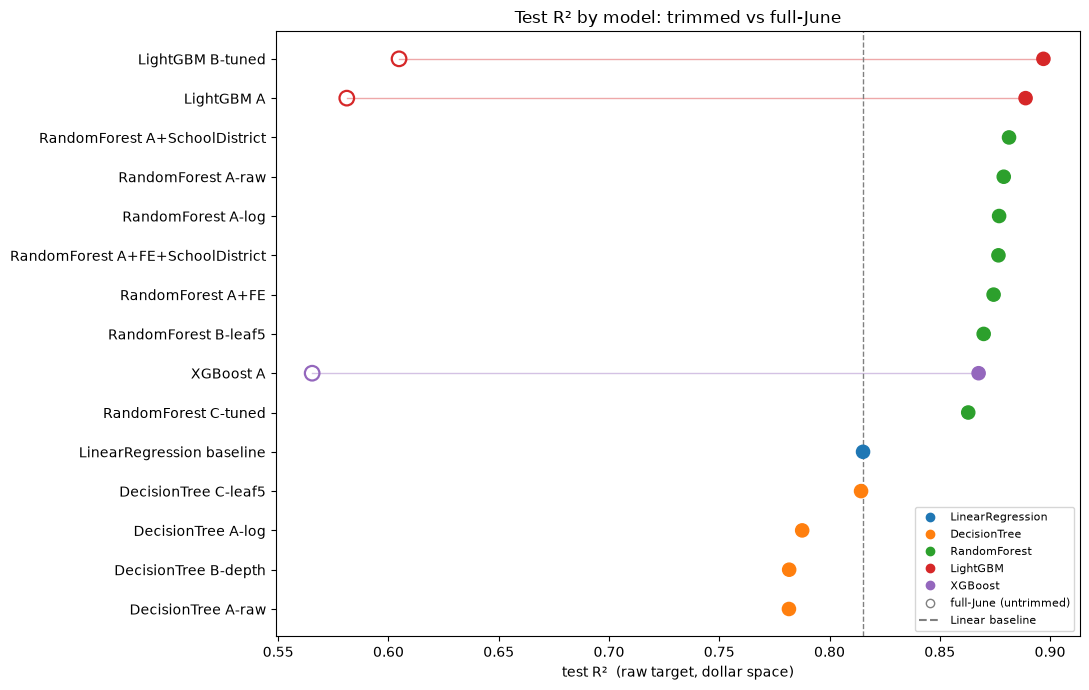

In [29]:
# Visualize the results across ALL models now
# LGBM and XGB both have the untrimmed test R^2 as noted by the hollow dots in plot

untrimmed = {
    "LightGBM|A": 0.5811,
    "LightGBM|B-tuned": 0.6048,
    "XGBoost|A": 0.5654,
}

untrimmed_results = {}

for key, var in untrimmed.items():
    if var in globals():
        pred = globals()[var]["model"].predict(test_df_full[feature])
        untrimmed_results[key] = round(r2_score(test_df_full[TARGET], pred), 4)

d = pd.read_csv(RESULTS)
d["key"] = d["model"] + "|" + d["version"]

unknown = [k for k in untrimmed_results if k not in set(d["key"])]
assert not unknown, f"untrimmed keys not in results log: {unknown}"
print(f"computed untrimmed for {len(untrimmed_results)} model(s): {untrimmed_results}")

d = d.sort_values("test_r2").reset_index(drop=True)


fam_color = {"LinearRegression": "tab:blue", "DecisionTree": "tab:orange",
             "RandomForest": "tab:green", "LightGBM": "tab:red", "XGBoost": "tab:purple"}
colors = d["model"].map(fam_color).fillna("gray")

fig, ax = plt.subplots(figsize=(11, 7))
y = range(len(d))
ax.scatter(d["test_r2"], y, c=colors, s=90, zorder=3, label="trimmed contract")

# overlay full-June where known
for yi, k in zip(y, d["key"]):
    if k in full_june:
        ax.scatter(full_june[k], yi, facecolors="none", edgecolors=colors.iloc[yi],
                   s=110, linewidths=1.6, zorder=3)
        ax.plot([full_june[k], d["test_r2"].iloc[yi]], [yi, yi],
                color=colors.iloc[yi], lw=1, alpha=0.4, zorder=2)

ax.axvline(0.8152, ls="--", color="gray", lw=1, label="Linear baseline (0.8152)")
ax.set_yticks(list(y))
ax.set_yticklabels([f'{m} {v}' for m, v in zip(d["model"], d["version"])])
ax.set_xlabel("test R²  (raw target, dollar space)")

ax.set_title(f"Test R² by model: trimmed vs full-June")
handles = [plt.Line2D([0],[0], marker='o', ls='', color=c, label=f) for f,c in fam_color.items()]
handles.append(plt.Line2D([0],[0], marker='o', ls='', mfc='none', mec='gray', label='full-June (untrimmed)'))
handles.append(plt.Line2D([0],[0], ls='--', color='gray', label='Linear baseline'))
ax.legend(handles=handles, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## Feature Engineering + District (from week 6)

In [ ]:
og = [c for c in df.columns if c not in EXCLUDE and not c.startswith("District_")]
district_cols = [c for c in df.columns if c.startswith("District_")]
engineered = ["BedBathRatio", "PropertyAge", "LotToLiving_log",
              "LivingAreaPerBedroom", "HasGarage", "AmenityCount"]

sets = {
    "Original":              og,
    "+engineered":           og + engineered,
    "+district":             og + district_cols,
    "+engineered+district":  og + engineered + district_cols,
}

lgbm_cfg = dict(**gb_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
# xgb_cfg  = dict(**xgb_search.best_params_, tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1)

rows = []
for name, feats in sets.items():
    lg = fit_eval(LGBMRegressor(**lgbm_cfg), use_log=False, X_tr=train_df[feats], X_te=test_df[feats])
    # xg = fit_eval(XGBRegressor(**xgb_cfg),  use_log=False, X_tr=train_df[feats], X_te=test_df[feats])
    rows.append({"feature_set": name, "n_features": len(feats),
                 "LightGBM": round(lg["test_r2"], 4)
                #  , "XGBoost": round(xg["test_r2"], 4)
                })

gbm_fe = pd.DataFrame(rows)
print(gbm_fe.to_string(index=False))

         feature_set  n_features  LightGBM
            Original        1185    0.8970
         +engineered        1191    0.8967
           +district        1547    0.8989
+engineered+district        1553    0.8977


Note: commented out xgb since the model takes too long to run and is inefficient

# Individual engineered features + district on LightGBM (tuned config)

In [ ]:
base = og + district_cols          # district base, matching the RF individual ablation
lgbm_cfg = dict(**gb_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

def run_lgbm(feats):
    r = fit_eval(LGBMRegressor(**lgbm_cfg), use_log=False,
                 X_tr=train_df[feats], X_te=test_df[feats])
    return r["test_r2"]

sets = {"+district (base)": base}
for f in engineered:
    sets[f"+district +{f}"] = base + [f]
sets["+district +all eng"] = base + engineered

rows = [{"feature_set": name, "n_features": len(feats), "LightGBM": round(run_lgbm(feats), 4)}
        for name, feats in sets.items()]
lgbm_indiv = pd.DataFrame(rows)
print(lgbm_indiv.to_string(index=False))

                    feature_set  n_features  LightGBM
               +district (base)        1547    0.8989
        +district +BedBathRatio        1548    0.8982
         +district +PropertyAge        1548    0.8995
     +district +LotToLiving_log        1548    0.8977
+district +LivingAreaPerBedroom        1548    0.9007
           +district +HasGarage        1548    0.8989
        +district +AmenityCount        1548    0.8991
             +district +all eng        1553    0.8977


### Interpret:

+district +LivingAreaPerBedroom        1548    0.9007

My original assumption was that LightGBM would perform best with just the addition of SchoolDistrict (like RF did), since already the engineered features had a similar effect in reducing the R^2 result when added to LightGBM. However, when looking at the individuals, LivingAreaPerBedroom and PropertyAge each boost the R^2 when seperately added to SchoolDistrict. 

This leads to my next check: would PropertyAge + LivingAreaPerBedroom + district win over district + LivingAreaPerBedroom (0.9007), potentially could optimize the June test set:

### side experiment: does adding PropertyAge + LivingAreaPerBedroom improve LightGBM?

`LivingAreaPerBedroom` (+0.0018) and `PropertyAge` (+0.0006) were the only engineered features to individually increase LightGBM

In [33]:
combo = og + district_cols + ["PropertyAge", "LivingAreaPerBedroom"]
r = fit_eval(LGBMRegressor(**lgbm_cfg), use_log=False, X_tr=train_df[combo], X_te=test_df[combo])
full = r2_score(test_df_full[TARGET], r["model"].predict(test_df_full[combo])) #untrimmed check as well
print(f"+district +PropertyAge +LivingAreaPerBedroom =")
print(f"  trimmed: {r['test_r2']:.4f}  \n"
      "          (base LGBM = 0.8989, base+district+LivingAreaPerBedroom = 0.9007)")
print(f"  full-June  : {full:.4f}")

+district +PropertyAge +LivingAreaPerBedroom =
  trimmed: 0.9000  
          (base LGBM = 0.8989, base+district+LivingAreaPerBedroom = 0.9007)
  full-June  : 0.6103


In [ ]:
# Cross validation checks for the combo vs base feature sets

order = np.argsort(train_df[DATE].to_numpy())
base_feats  = og + district_cols
combo_feats = og + district_cols + ["PropertyAge", "LivingAreaPerBedroom"]
y_sorted = train_df.iloc[order][TARGET].reset_index(drop=True)

for label, feats in [("+district (base)", base_feats),
                     ("+district +PropertyAge +LivingAreaPerBedroom", combo_feats)]:
    X_sorted = train_df.iloc[order][feats].reset_index(drop=True)
    scores = cross_val_score(LGBMRegressor(**lgbm_cfg), X_sorted, y_sorted,
                             cv=monthly_splits, scoring="r2", n_jobs=-1)
    folds = "  ".join(f"{s:.3f}" for s in scores)
    print(f"{label:30} mean {scores.mean():.4f}  |  folds: {folds}")

+district (base)               mean 0.8950  |  folds: 0.889  0.895  0.897  0.899
+district +PropAge +LivPerBed  mean 0.8945  |  folds: 0.891  0.893  0.896  0.899


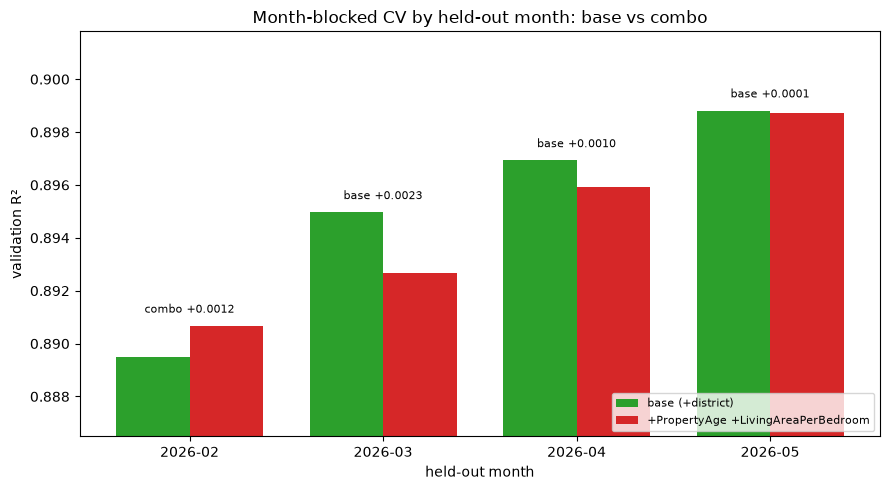

In [39]:
# Per-month visualization of the district only vs combo feature sets

order = np.argsort(train_df[DATE].to_numpy())
per_sorted = train_df.iloc[order][DATE].dt.to_period("M").reset_index(drop=True)
val_months = [str(m) for m in sorted(per_sorted.unique())[-4:]]

def per_month_scores(feats):
    Xs = train_df.iloc[order][feats].reset_index(drop=True)
    ys = train_df.iloc[order][TARGET].reset_index(drop=True)
    return np.array([
        r2_score(ys.iloc[va],
                 LGBMRegressor(**lgbm_cfg).fit(Xs.iloc[tr], ys.iloc[tr]).predict(Xs.iloc[va]))
        for tr, va in monthly_splits
    ])

base_s  = per_month_scores(og + district_cols)
combo_s = per_month_scores(og + district_cols + ["PropertyAge", "LivingAreaPerBedroom"])

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(val_months)); w = 0.38
ax.bar(x - w/2, base_s,  w, label="base (+district)",    color="tab:green")
ax.bar(x + w/2, combo_s, w, label="+PropertyAge +LivingAreaPerBedroom", color="tab:red")

for xi, (b, c) in enumerate(zip(base_s, combo_s)):
    winner = "base" if b >= c else "combo"
    ax.text(xi, max(b, c) + 0.0005, f"{winner} +{abs(b - c):.4f}", ha="center", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(val_months)
lo = min(base_s.min(), combo_s.min()); hi = max(base_s.max(), combo_s.max())
ax.set_ylim(lo - 0.003, hi + 0.003)   # zoom into the noise band so per-month gaps are visible
ax.set_ylabel("validation R²"); ax.set_xlabel("held-out month")
ax.set_title("Month-blocked CV by held-out month: base vs combo")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()


### Interpret:

- Combining the individually stronger feature engineerings with the base and school district of LightGBM didn't make the result any stronger than the base + school district + LivingArea per Bedroom. 

- validated it with month-blocked cross-validation on the training months only
- cross-validation show base (+district) is better and wins or ties in every month of the folding (showing the noise floor)

- Best LightGBM for modelling the dataframe is the base + SchoolDistrict

## Final Model Summary

Best model: `LightGBM B-tuned`

- trimmed R^2 = 0.8970  (train 0.9501, gap 0.0531)
- full-June R^2 = 0.6048

- baselinle: R^2 = 0.8152

- New Ranking:
LightGBM Gradient boosting > Random Forest > Linear > Decision Tree, on both accuracy and train/test gap

- Engineered feature ratios doens't help any tree models
    - supports Linear only
- XGBoost matches LightGBM's range but is extremely slow, so LGBM takes lead anyway

# Findings across the models

Geography (school district on top of ZIP/City):
  - RF:       +0.002   (redundant; lat-long + ZIP/City already encode location)
  - LightGBM: +0.002   ( redundant for boosting too)

- District adds such a small difference to any tree model, Zip and City make the most difference

Engineered ratios (Bed/Bath, Age, Lot/Living, LivAreaPerBed, HasGarage, AmenityCount):
  - Linear:   +0.015   (helps significantly, linear can't build interactions itself)
  - RF:       no or worse effect
  - LightGBM: LivingAreaPerBedroom +0.0018 but not consistently in the untrimmed version

Engineered features help Linear, are neutral/noisy for tree ensembles.

Model ranking (trimmed contract / honest full-June):
  - LightGBM B-tuned : 0.897 / 0.605
  - RandomForest   : 0.870 / 0.552
  - Linear baseline  : 0.815 / 0.523